# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [7]:
pip install scikit.learn

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl (8.0 MB)
Using cached joblib-1.5.3-py3-none-any.whl (309 kB)
Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl (36.5 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)

   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ----------------------------- 1/4 [scipy]
   ---------- ------------------


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [9]:
# untuk plot Q-Q
import scipy.stats as stats

In [10]:
df_california = pd.read_csv('california_dataset.csv')

In [11]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

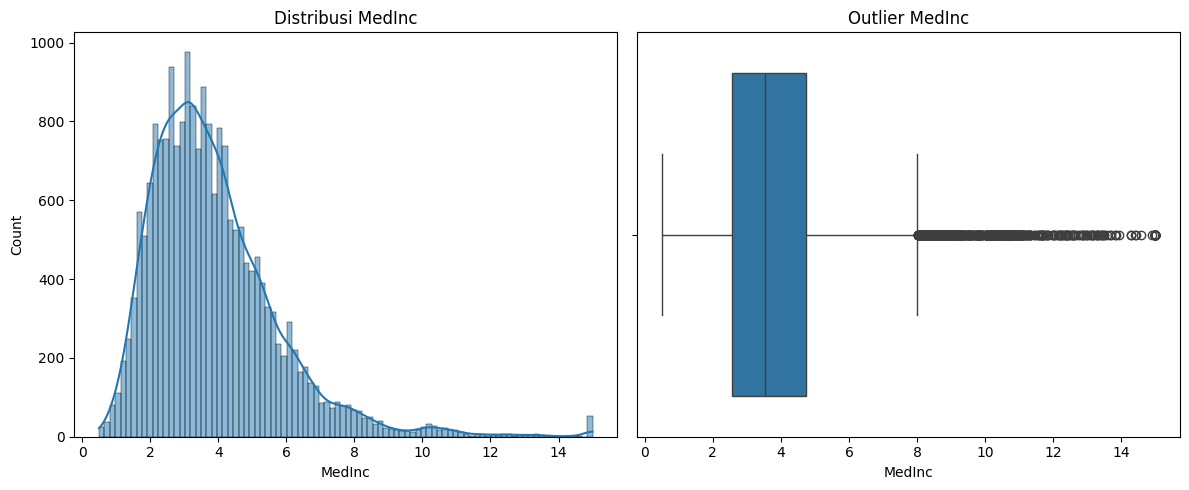

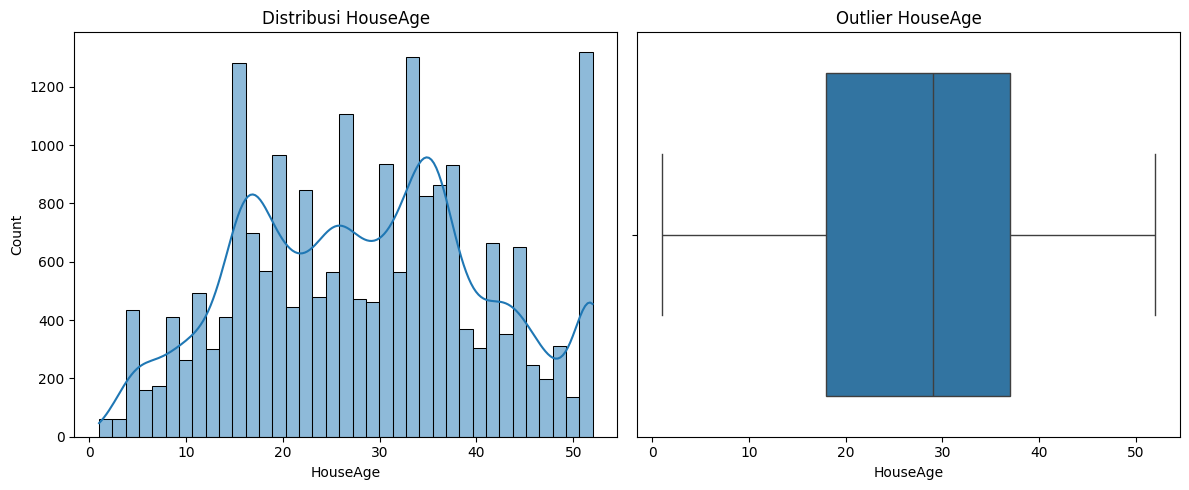

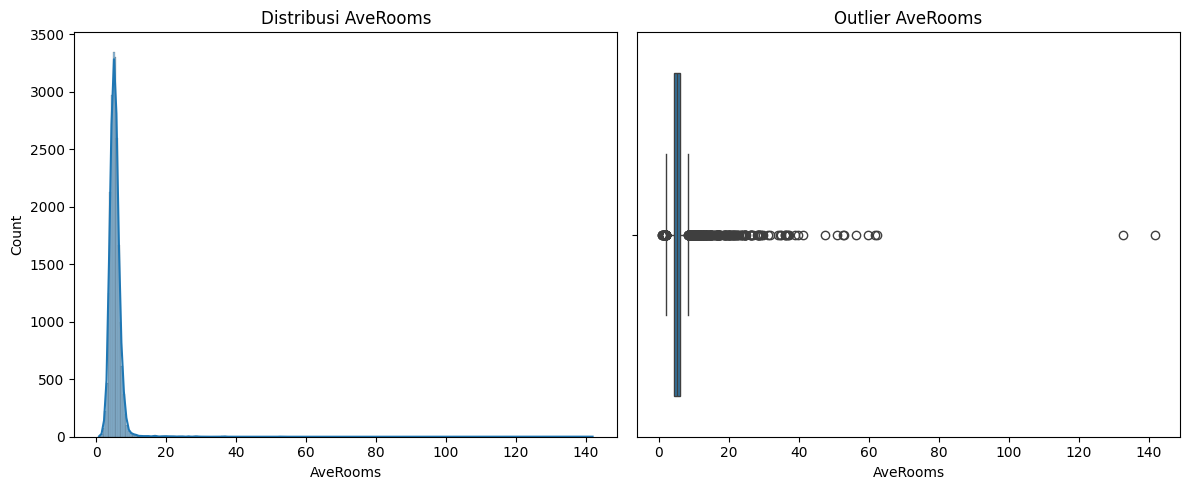

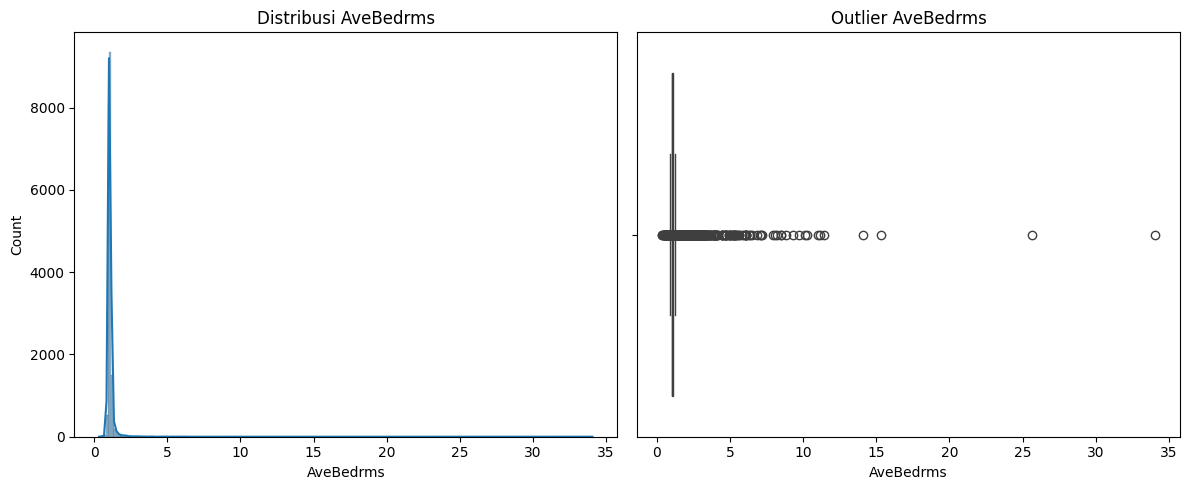

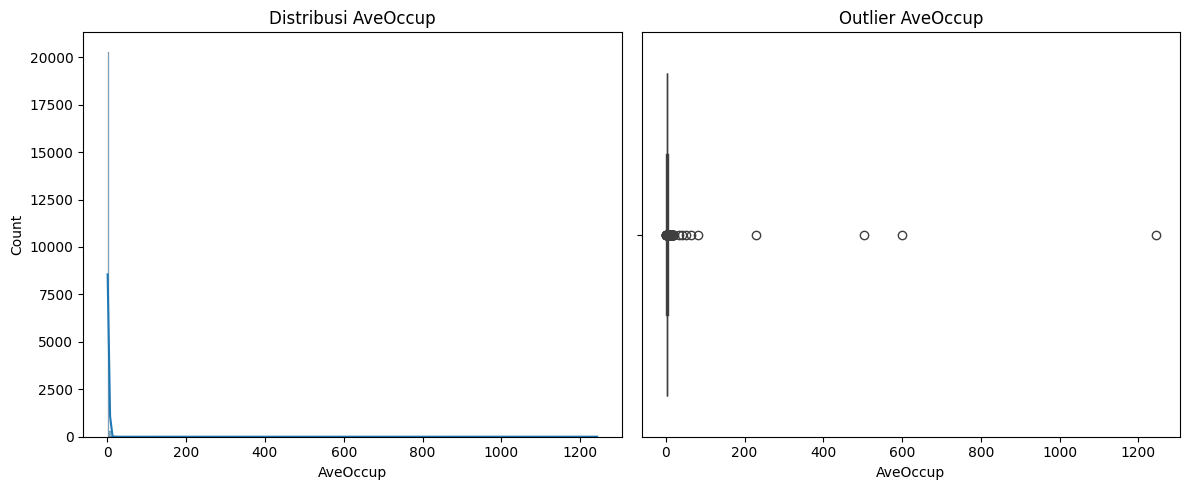

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Membaca dataset
df = pd.read_csv('california_dataset.csv')

# Daftar kolom yang ingin dicek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

# Looping untuk menampilkan distribusi dan outlier
for kolom in kolom_kolom:
    
    plt.figure(figsize=(12,5))
    
    # Histogram (Distribusi data)
    plt.subplot(1,2,1)
    sns.histplot(df[kolom], kde=True)
    plt.title(f'Distribusi {kolom}')
    
    # Boxplot (Outlier)
    plt.subplot(1,2,2)
    sns.boxplot(x=df[kolom])
    plt.title(f'Outlier {kolom}')
    
    plt.tight_layout()
    plt.show()


### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

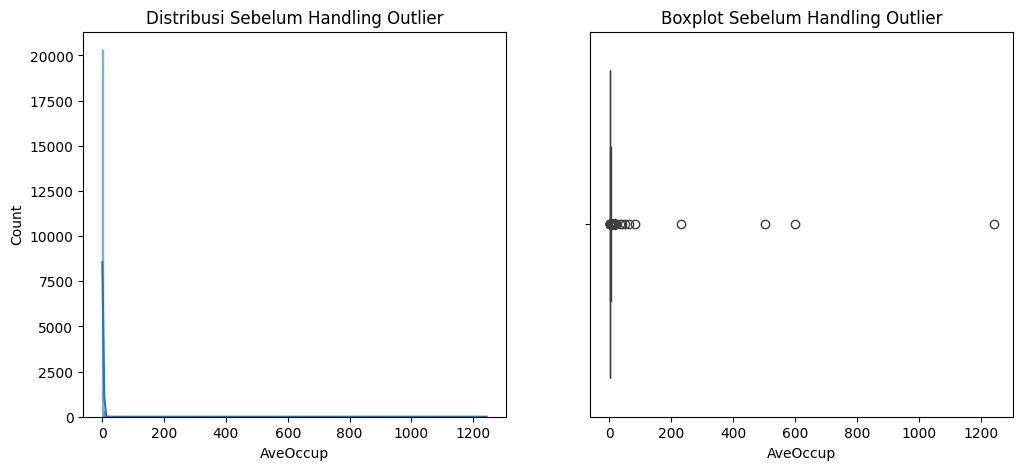

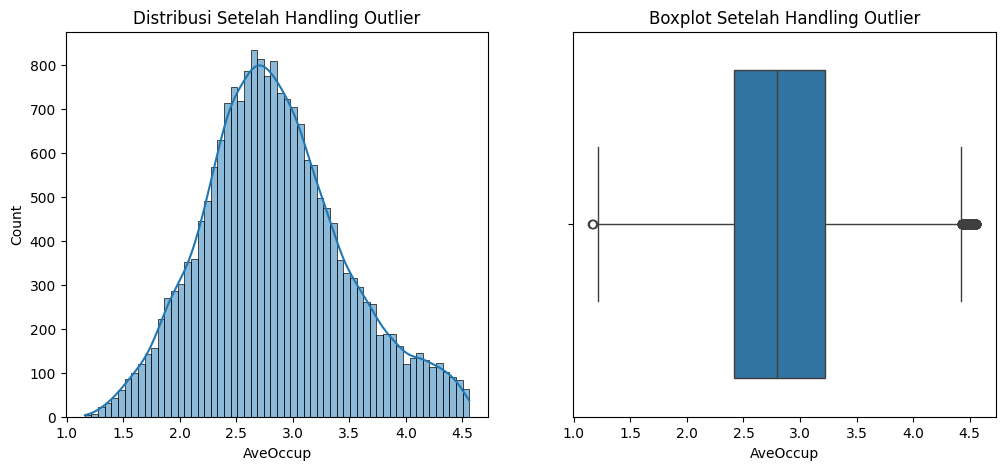

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Pilih 1 kolom untuk handling outlier
kolom = 'AveOccup'

# =========================
# 1. Cek distribusi sebelum handling
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df[kolom], kde=True)
plt.title('Distribusi Sebelum Handling Outlier')

plt.subplot(1,2,2)
sns.boxplot(x=df[kolom])
plt.title('Boxplot Sebelum Handling Outlier')

plt.show()

# =========================
# 2. Menghitung IQR
# =========================
Q1 = df[kolom].quantile(0.25)
Q3 = df[kolom].quantile(0.75)
IQR = Q3 - Q1

# Batas bawah dan atas
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# =========================
# 3. Menghapus outlier
# =========================
df_clean = df[(df[kolom] >= lower_bound) & (df[kolom] <= upper_bound)]

# =========================
# 4. Cek distribusi setelah handling
# =========================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_clean[kolom], kde=True)
plt.title('Distribusi Setelah Handling Outlier')

plt.subplot(1,2,2)
sns.boxplot(x=df_clean[kolom])
plt.title('Boxplot Setelah Handling Outlier')

plt.show()


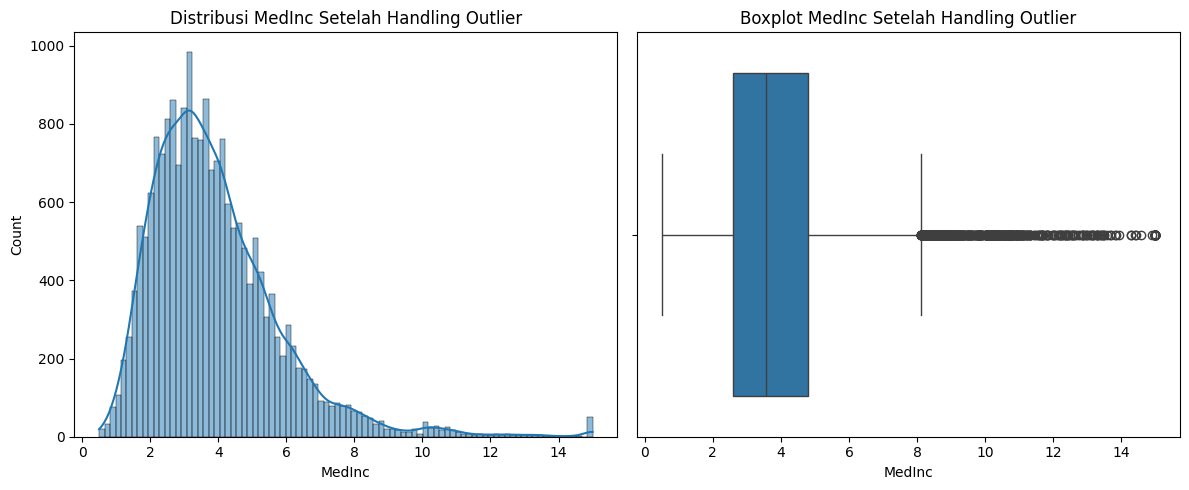

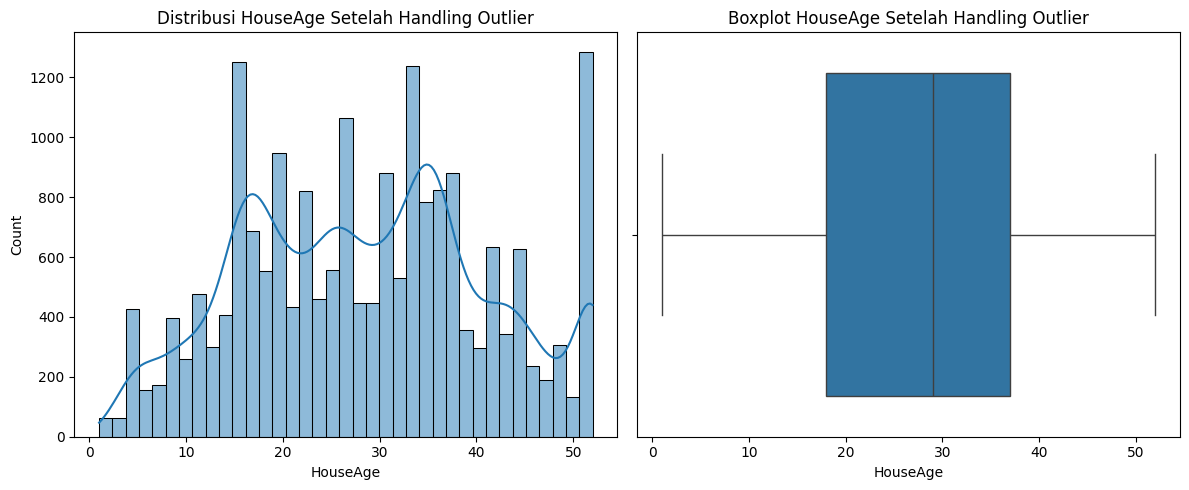

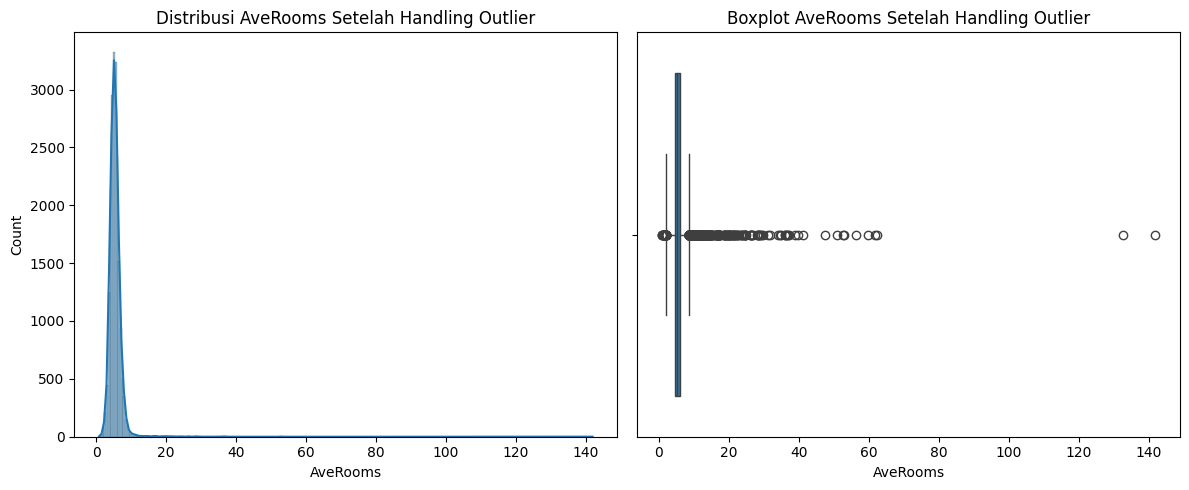

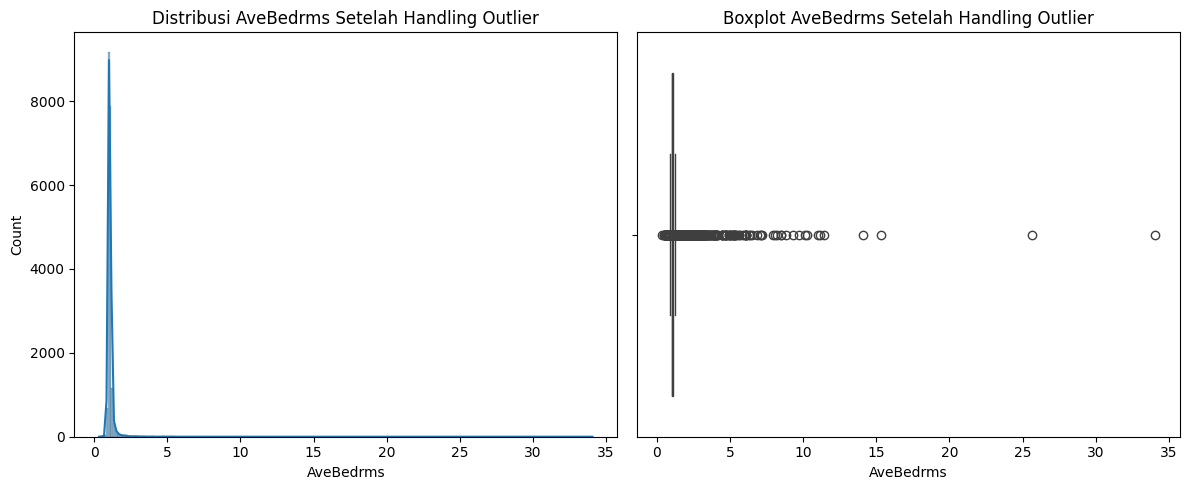

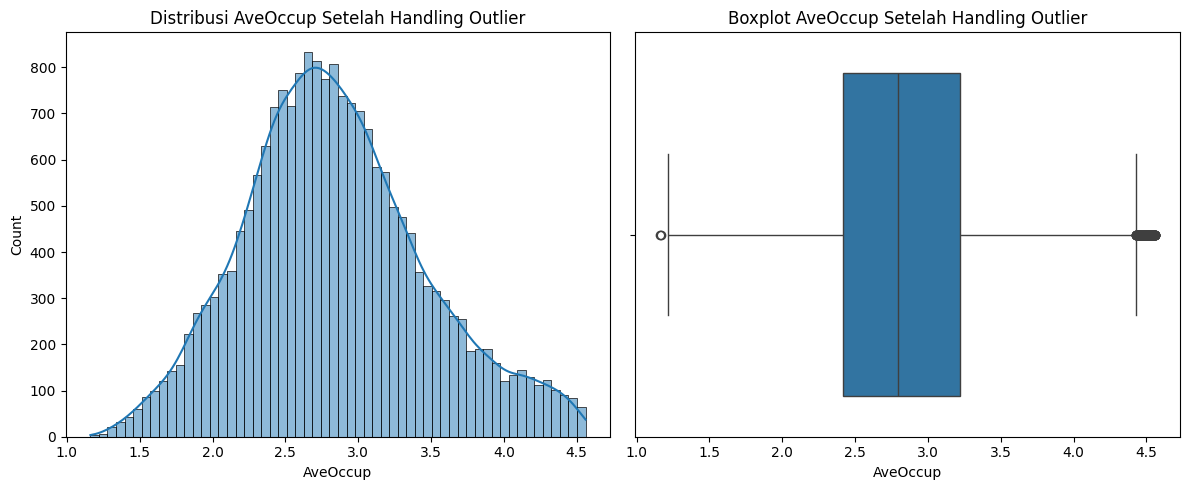

In [14]:
# Melakukan loop untuk mengecek distribusi tiap kolom

kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for kolom in kolom_kolom:
    
    plt.figure(figsize=(12,5))
    
    # Histogram distribusi
    plt.subplot(1,2,1)
    sns.histplot(df_clean[kolom], kde=True)
    plt.title(f'Distribusi {kolom} Setelah Handling Outlier')
    
    # Boxplot untuk melihat outlier
    plt.subplot(1,2,2)
    sns.boxplot(x=df_clean[kolom])
    plt.title(f'Boxplot {kolom} Setelah Handling Outlier')
    
    plt.tight_layout()
    plt.show()


# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [15]:
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [16]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [17]:
# Missing Value Handling Kolom Headquarters

# 1. Persentase missing value pada kolom Headquarters dihitung untuk mengetahui
# seberapa banyak data yang hilang pada kolom tersebut.

# 2. Berdasarkan pengecekan, jenis missing value yang ditemukan biasanya berupa
# nilai NaN (Not a Number) atau data kosong.

# 3. Jika persentase missing value lebih dari 20%, maka kolom tersebut sebaiknya di-drop
# karena terlalu banyak data yang hilang.

# 4. Jika persentase missing value kurang dari atau sama dengan 20%, maka kolom
# tidak perlu dihapus dan dapat dilakukan proses handling missing value.

# 5. Karena kolom Headquarters merupakan tipe data kategorikal (nama lokasi kantor),
# maka metode yang paling sesuai untuk mengisi missing value adalah menggunakan
# nilai modus (nilai yang paling sering muncul).

In [18]:
import pandas as pd

# Membaca dataset
df_company = pd.read_csv('company.csv')

# 1. Mengecek jumlah missing value pada kolom Headquarters
missing_count = df_company['Headquarters'].isnull().sum()

# 2. Menghitung persentase missing value
missing_percent = (missing_count / len(df_company)) * 100

print("Jumlah missing value:", missing_count)
print("Persentase missing value:", missing_percent, "%")

# 3. Menentukan apakah kolom perlu di drop atau tidak
if missing_percent > 20:
    df_company = df_company.drop(columns=['Headquarters'])
    print("Kolom Headquarters di-drop karena missing value > 20%")
else:
    # 4. Handling missing value dengan modus
    mode_value = df_company['Headquarters'].mode()[0]
    df_company['Headquarters'].fillna(mode_value, inplace=True)
    print("Missing value diisi menggunakan modus:", mode_value)

# 5. Mengecek kembali missing value setelah handling
print("\nMissing value setelah handling:")
print(df_company['Headquarters'].isnull().sum())

Jumlah missing value: 0
Persentase missing value: 0.0 %
Missing value diisi menggunakan modus: New York, NY

Missing value setelah handling:
0


C:\Users\user\AppData\Local\Temp\ipykernel_15584\2611954903.py:22: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df_company['Headquarters'].fillna(mode_value, inplace=True)


# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [19]:
df_churn = pd.read_csv(r"C:\Users\user\Documents\Matkul Semester 6\machine learning\Practice 2\TelcoCustomerChurn.csv")

In [21]:
import pandas as pd

# Pastikan hasil read_csv dimasukkan ke variabel 'df'
df = pd.read_csv(r"C:\Users\user\Documents\Matkul Semester 6\machine learning\Practice 2\TelcoCustomerChurn.csv")

# Cek nama kolom yang tersedia
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [22]:
from sklearn.preprocessing import LabelEncoder

# 1. Pilih kolom-kolom yang ditentukan
cols_to_encode = [
    'StreamingMovies', 'StreamingTV', 'TechSupport', 
    'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines'
]

In [23]:
# 2. Ganti nilai yang tidak sesuai
for col in cols_to_encode:
    df[col] = df[col].replace('No internet service', 'No')
    df[col] = df[col].replace('No phone service', 'No') # Tambahan untuk MultipleLines jika ada

# Validasi dengan value_counts untuk salah satu kolom (contoh: StreamingMovies)
print(df['StreamingMovies'].value_counts())

StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64


In [25]:
# Lakukan train-test split sebelum label encoding
from sklearn.model_selection import train_test_split

# 1. Pisahkan features (X) dan target (y)
# Asumsikan 'Churn' adalah target variable
X = df.drop(columns=['Churn', 'customerID'])  # Buang target dan ID
y = df['Churn']

# 2. Lakukan train-test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (5634, 19)
X_test shape: (1409, 19)


In [26]:
# 3. Kemudian lakukan label Encoder
le = LabelEncoder()

for col in cols_to_encode:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

# Menampilkan hasil transformasi pertama
X_train[cols_to_encode].head()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
2142,1,0,0,1,0,1,0
1623,1,1,0,0,1,0,1
6074,0,0,0,0,0,0,0
1362,0,0,0,0,0,0,0
6754,0,0,1,0,1,1,1


In [27]:
# Cek tipe data setelah encoding
print(X_train[cols_to_encode].dtypes)

# Menampilkan data unik setelah encoding
for col in cols_to_encode:
    print(f"Unique values in {col}: {X_train[col].unique()}")

StreamingMovies     int64
StreamingTV         int64
TechSupport         int64
DeviceProtection    int64
OnlineBackup        int64
OnlineSecurity      int64
MultipleLines       int64
dtype: object
Unique values in StreamingMovies: [1 0]
Unique values in StreamingTV: [0 1]
Unique values in TechSupport: [0 1]
Unique values in DeviceProtection: [1 0]
Unique values in OnlineBackup: [0 1]
Unique values in OnlineSecurity: [1 0]
Unique values in MultipleLines: [0 1]


## Selesai :)